In [1]:
# === 로컬 환경 셋업 ===
import os, sys, torch

PROJECT_DIR = os.getcwd()
DATA_PATH   = os.path.join(PROJECT_DIR, 'data')        # KITTI 등 대용량 데이터
IMAGE_PATH  = os.path.join(PROJECT_DIR, 'images')      # 평가용 stop_*.png / go_*.png
CKPT_PATH   = os.path.join(DATA_PATH, 'checkpoints')   # 학습 체크포인트
for _d in (DATA_PATH, IMAGE_PATH, CKPT_PATH):
    os.makedirs(_d, exist_ok=True)

# 2) GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

NUM_WORKERS = 0 if sys.platform.startswith('win') else 2

_t = torch
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load

try:
    import matplotlib
    matplotlib.rcParams['axes.unicode_minus'] = False
except Exception:
    pass

print('python     :', sys.version.split()[0])
print('torch      :', torch.__version__)
print('device     :', device)
if device.type == 'cuda':
    print('GPU        :', torch.cuda.get_device_name(0),
          f'({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)')
print('NUM_WORKERS:', NUM_WORKERS)
print('DATA_PATH  :', DATA_PATH)
print('IMAGE_PATH :', IMAGE_PATH)


python     : 3.12.13
torch      : 2.11.0+cu128
device     : cuda
GPU        : NVIDIA GeForce RTX 5070 Ti Laptop GPU (11.9 GB)
NUM_WORKERS: 0
DATA_PATH  : C:\Aiffel\AIFFEL_quest_rs\GoingDeeper\Deep02\data
IMAGE_PATH : C:\Aiffel\AIFFEL_quest_rs\GoingDeeper\Deep02\images


# 들어가며

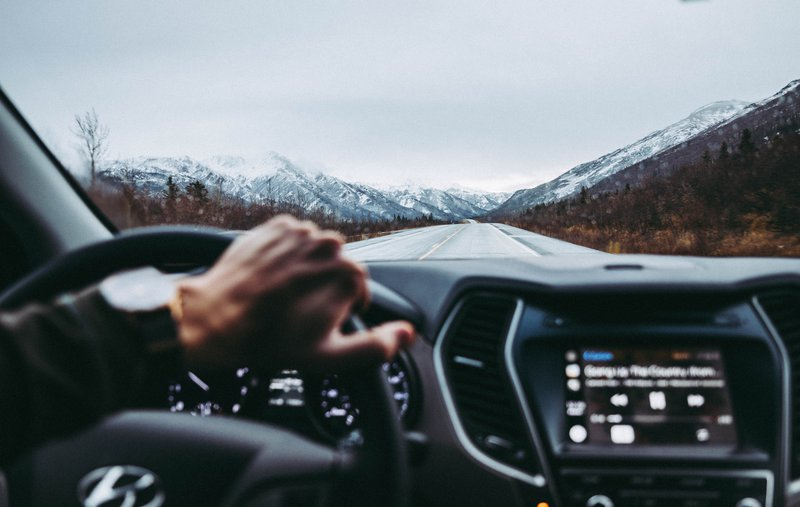

https://unsplash.com/photos/mpSeLIXMnpc

이번 시간에는 object detection 모델을 통해 주변에 다른 차나 사람이 가까이 있는지 확인한 후 멈출 수 있는 자율주행 시스템을 만들어 보겠습니다. 하지만 자율주행 시스템은 아직 완전하지 않기 때문에, 위험한 상황에서는 운전자가 직접 운전할 수 있도록 하거나 판단이 어려운 상황에서는 멈추도록 설계됩니다. 우리도 같은 구조를 가진 미니 자율주행 보조장치를 만들어 볼 겁니다.

## 실습 목표
---
  1. Object detection 모델을 학습할 수 있습니다.
  2. RetinaNet 모델을 활용한 시스템을 만들 수 있습니다.


## 학습 내용
---
  1. 자율주행 보조장치
  2. RetinaNet
  3. 데이터 준비부터 모델 학습, 결과 확인까지
  4. 프로젝트: 자율주행 보조 시스템 만들기

# 자율주행 보조장치 (1) KITTI 데이터셋

이번 시간에 만들어 볼 자율주행 보조장치는 카메라에 사람이 탐지되었을 때, 그리고 차가 가까워져서 탐지된 크기가 일정 크기 이상일 때를 판단해야 합니다.

>자율주행 보조장치 object detection 요구사항
  - 1. 사람이 카메라에 감지되면 정지
  - 2. 차량이 일정 크기 이상으로 감지되면 정지

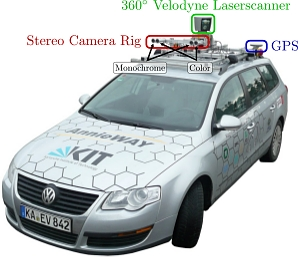

https://www.cvlibs.net/datasets/kitti/

이번 시간에는 `torchvision.datasets`에서 제공하는 KITTI 데이터셋(`torchvision.datasets.Kitti`)을 사용해보겠습니다. KITTI 데이터셋은 자율주행을 위한 데이터셋으로 2D object detection 뿐만 아니라 깊이까지 포함한 3D object detection 라벨 등을 제공하고 있습니다.

  - [cvlibs에서 제공하는 KITTI 데이터셋](https://www.cvlibs.net/datasets/kitti/)

먼저 필요한 라이브러리를 불러 오겠습니다.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as NF                     # nn.functional (relu, one_hot, bce ...)
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF       # 이미지 변환용 (resize, pad, hflip ...)
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset, random_split

import os, copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

아래 코드를 통해서 KITTI 데이터셋을 다운로드해 주세요. 30-40분 정도 걸립니다.

>(주의) 이 데이터셋은 11GB가 넘어가는 대용량 데이터셋입니다. 다운로드 소요시간이 수시간 이상 지속될 수 있으니, 다운로드는 가급적 별도의 jupyter notebook에서 수행하시기를 권합니다.

In [3]:
# torchvision이 제공하는 KITTI(2D object detection) 데이터셋을 내려받습니다.
# 최초 실행 시 이미지+라벨(약 12GB)을 다운로드하므로 시간이 걸립니다.
kitti_train = torchvision.datasets.Kitti(root=DATA_PATH, train=True, download=False)
kitti_test  = torchvision.datasets.Kitti(root=DATA_PATH, train=False, download=False)

# KITTI의 8개 클래스(과거 tfds 버전과 동일, 'DontCare'는 제외)
KITTI_CLASSES = ['Car', 'Van', 'Truck', 'Pedestrian',
                 'Person_sitting', 'Cyclist', 'Tram', 'Misc']
NAME_TO_ID = {name: i for i, name in enumerate(KITTI_CLASSES)}

def parse_kitti_target(target):
    """torchvision KITTI 타깃(list of dict) -> (boxes[xyxy px], class_ids)."""
    boxes, cls_ids = [], []
    for obj in (target or []):
        name = obj['type']
        if name not in NAME_TO_ID:          # 'DontCare' 등은 건너뜀
            continue
        boxes.append(obj['bbox'])           # [x_min, y_min, x_max, y_max] (픽셀)
        cls_ids.append(NAME_TO_ID[name])
    boxes = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)
    cls_ids = torch.tensor(cls_ids, dtype=torch.int64)
    return boxes, cls_ids

다운로드한 KITTI 데이터셋에서 학습 이미지 몇 장을 바운딩 박스와 함께 직접 그려 확인해봅시다. 우리가 일반적으로 보는 사진보다 광각으로 촬영되어 다양한 각도의 물체를 확인할 수 있습니다.

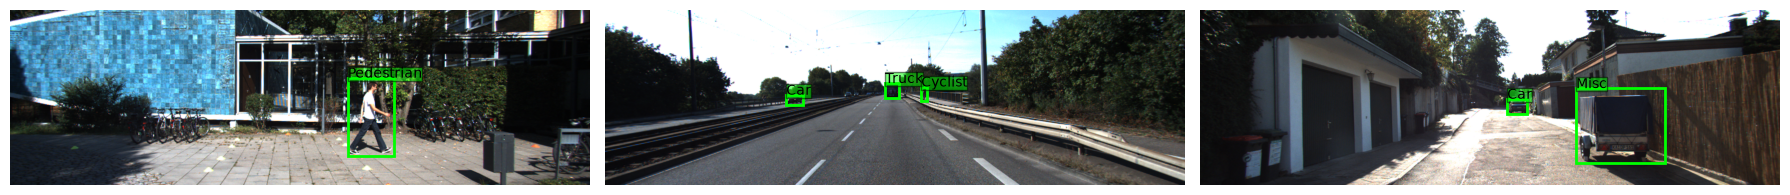

In [4]:
# tfds.show_examples 대신, 학습 데이터 몇 장을 바운딩 박스와 함께 직접 그려봅니다.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, idx in zip(axes, range(3)):
    image, target = kitti_train[idx]
    ax.imshow(image)
    for obj in target:
        if obj['type'] not in NAME_TO_ID:
            continue
        x1, y1, x2, y2 = obj['bbox']
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor='lime', linewidth=2))
        ax.text(x1, y1, obj['type'], color='black',
                bbox={'facecolor': 'lime', 'alpha': 0.5, 'pad': 0})
    ax.axis('off')
plt.tight_layout()
plt.show()

아래 코드로 데이터셋의 크기와 클래스 정보를 확인할 수 있습니다. torchvision이 제공하는 KITTI(object detection)는 라벨이 있는 **학습용 이미지 7,481장**과 라벨이 없는 **평가용 이미지 7,518장**으로 구성됩니다. 각 객체의 라벨에는 `type`(클래스명), `bbox`(x_min, y_min, x_max, y_max 픽셀 좌표), `truncated`, `occluded`, `alpha`, `dimensions`, `location`, `rotation_y` 등의 정보가 담겨 있습니다.

In [5]:
# 데이터셋 정보 확인 (tfds의 ds_info 대체)
print(f"train 이미지 수: {len(kitti_train)}")
print(f"test  이미지 수: {len(kitti_test)}")
print(f"클래스({len(KITTI_CLASSES)}개): {KITTI_CLASSES}")

train 이미지 수: 7481
test  이미지 수: 7518
클래스(8개): ['Car', 'Van', 'Truck', 'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram', 'Misc']


# 자율주행 보조장치 (2) 데이터 직접 확인하기

이번에는 데이터셋을 직접 확인하는 시간을 갖도록 하겠습니다. `kitti_train[0]`처럼 인덱싱하면 데이터셋에서 샘플을 하나씩 뽑아볼 수 있습니다. 이렇게 뽑은 데이터는 `(PIL 이미지, 타깃 리스트)` 형태이며, 타깃 리스트의 각 원소는 `type`(클래스명), `bbox`(x_min, y_min, x_max, y_max 픽셀 좌표) 등의 정보를 담은 딕셔너리입니다.

눈으로 확인해서 학습에 사용할 데이터를 직접 이해해 봅시다.

------ target(첫 번째 객체) ------
{'type': 'Pedestrian', 'truncated': 0.0, 'occluded': 0, 'alpha': -0.2, 'bbox': [712.4, 143.0, 810.73, 307.92], 'dimensions': [1.89, 0.48, 1.2], 'location': [1.84, 1.47, 8.41], 'rotation_y': 0.01}
------ 파싱 결과 ------
boxes(xyxy, px): torch.Size([1, 4])
class_ids     : [3]


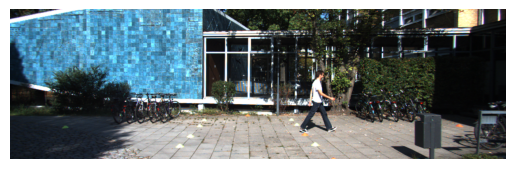

In [6]:
# kitti_train[0] 으로 (이미지, 타깃) 하나를 뽑아 직접 확인해봅니다.
image, target = kitti_train[0]

print('------ target(첫 번째 객체) ------')
print(target[0])

boxes, cls_ids = parse_kitti_target(target)
print('------ 파싱 결과 ------')
print('boxes(xyxy, px):', boxes.shape)
print('class_ids     :', cls_ids.tolist())

plt.imshow(image)
plt.axis('off')
plt.show()

이미지와 라벨을 얻는 방법을 알게 되었습니다. 그렇다면 이렇게 얻은 이미지의 바운딩 박스(bounding box, bbox)를 확인하기 위해서는 어떻게 해야 할까요?

아래는 KITTI에서 제공하는 데이터셋에 대한 설명입니다.



```
데이터셋 이해를 위한 예시
Values    Name      Description
----------------------------------------------------------------------------
   1    type         Describes the type of object: 'Car', 'Van', 'Truck',
                     'Pedestrian', 'Person_sitting', 'Cyclist', 'Tram',
                     'Misc' or 'DontCare'
   1    truncated    Float from 0 (non-truncated) to 1 (truncated), where
                     truncated refers to the object leaving image boundaries
   1    occluded     Integer (0,1,2,3) indicating occlusion state:
                     0 = fully visible, 1 = partly occluded
                     2 = largely occluded, 3 = unknown
   1    alpha        Observation angle of object, ranging [-pi..pi]
   4    bbox         2D bounding box of object in the image (0-based index):
                     contains left, top, right, bottom pixel coordinates
   3    dimensions   3D object dimensions: height, width, length (in meters)
   3    location     3D object location x,y,z in camera coordinates (in meters)
   1    rotation_y   Rotation ry around Y-axis in camera coordinates [-pi..pi]
   1    score        Only for results: Float, indicating confidence in
                     detection, needed for p/r curves, higher is better.
```



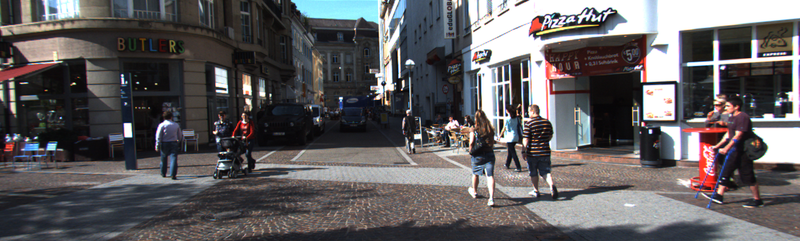

[KITTI 원본이미지 예시]

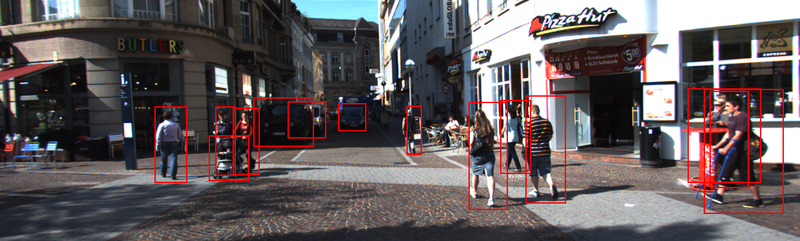

[KITTI 이미지 바운딩 박스 시각화 예시]


위 설명과 예시 이미지를 참고하셔서 이미지 위에 바운딩 박스를 그려서 시각화해 보세요!

[Pillow 라이브러리의 ImageDraw 모듈](https://pillow.readthedocs.io/en/stable/reference/ImageDraw.html)을 참고하세요.

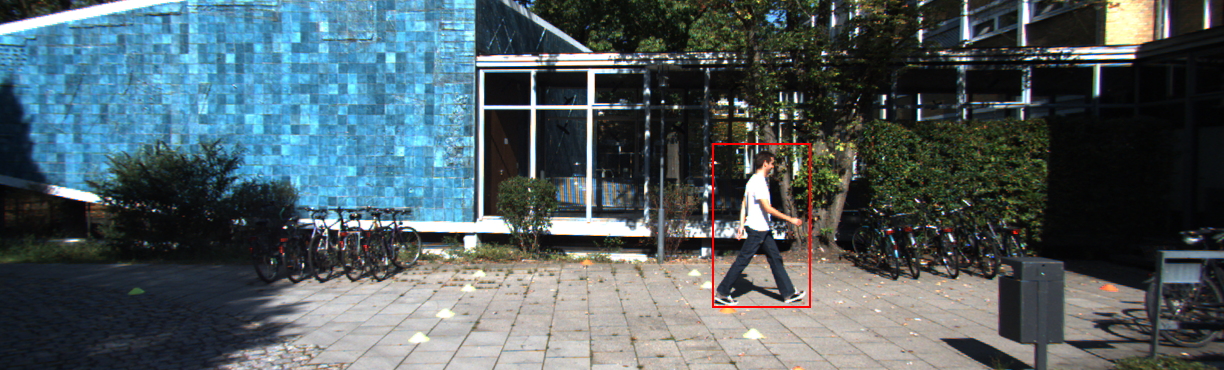

In [7]:
# 이미지 위에 바운딩 박스를 그려 화면에 표시해 주세요.
def visualize_bbox(input_image, target):
    input_image = copy.deepcopy(input_image)
    draw = ImageDraw.Draw(input_image)

    # torchvision KITTI는 bbox를 (x_min, y_min, x_max, y_max) 픽셀 좌표로 바로 제공합니다.
    for obj in target:
        if obj['type'] not in NAME_TO_ID:
            continue
        x_min, y_min, x_max, y_max = obj['bbox']
        draw.rectangle((x_min, y_min, x_max, y_max), outline=(255, 0, 0), width=2)

    return input_image

visualize_bbox(image, target)

# RetinaNet

  - [Focal Loss for Dense Object Detection](https://arxiv.org/abs/1708.02002)

RetinaNet은 **Focal Loss for Dense Object Detection** 논문을 통해 공개된 detection 모델입니다.

1-stage detector 모델인 YOLO와 SSD는 2-stage detector인 Faster-RCNN 등보다 속도는 빠르지만 성능이 낮은 문제를 가지고 있었습니다. 이를 해결하기 위해서 RetinaNet에서는 **focal loss**와 **FPN(Feature Pyramid Network)** 를 적용한 네트워크를 사용합니다.

## Focal Loss
---
>물체를 배경보다 더 잘 학습하자 == 물체인 경우 Loss를 작게 만들자

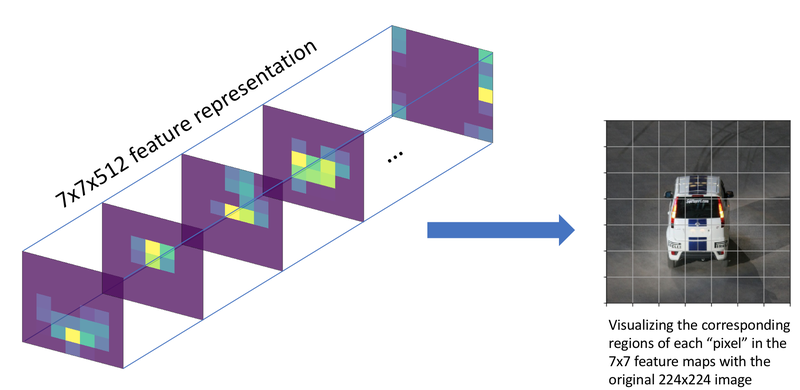

https://www.jeremyjordan.me/object-detection-one-stage/

Focal loss는 기존의 1-stage detection 모델들(YOLO, SSD)이 물체 전경과 배경을 담고 있는 모든 그리드(grid)에 대해 한 번에 학습됨으로 인해서 생기는 클래스 간의 불균형을 해결하고자 도입되었습니다. 여기서 그리드(grid)와 픽셀(pixel)이 혼란스러울 수 있겠는데, 위 그림 왼쪽 7x7 feature level에서는 한 픽셀이고, 오른쪽의 image level(자동차 사진)에서 보이는 그리드는 각 픽셀의 receptive field입니다.

그림에서 보이는 것처럼 우리가 사용하는 이미지는 물체보다는 많은 배경을 학습하게 됩니다. 논문에서는 이를 해결하기 위해서 Loss를 개선하여 정확도를 높였습니다.

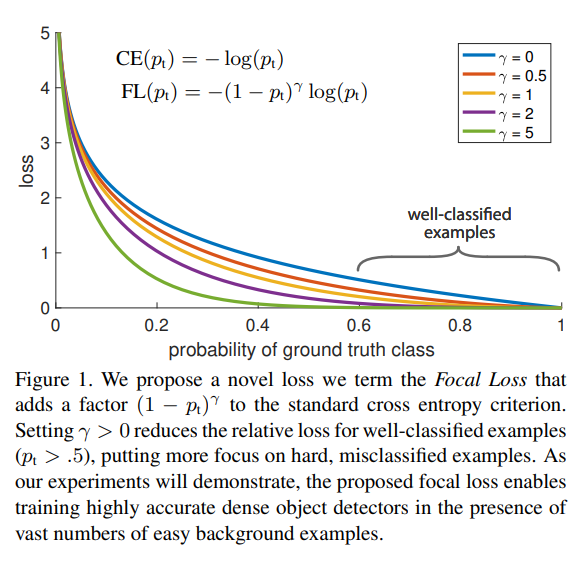

https://arxiv.org/abs/1708.02002

Focal loss는 우리가 많이 사용해왔던 교차 엔트로피를 기반으로 만들어졌습니다. 위 그림을 보면 Focal loss는 그저 교차 엔트로피 CE($p_t$)의 앞단에 간단히 ($1−p_t)^γ$라는 modulating factor를 붙여주었습니다.

교차 엔트로피의 개형을 보면 ground truth class에 대한 확률이 높으면 잘 분류된 것으로 판단되므로 손실이 줄어드는 것을 볼 수 있습니다. 하지만 확률이 1에 매우 가깝지 않은 이상 상당히 큰 손실로 이어지는데요.

이 상황은 물체 검출 모델을 학습시키는 과정에서 문제가 될 수 있습니다. 대부분의 이미지에서는 물체보다 배경이 많습니다. 따라서 이미지는 극단적으로 배경의 class가 많은 class imbalanced data라고 할 수 있습니다. 이렇게 너무 많은 배경 class에 압도되지 않도록 modulating factor로 손실을 조절해줍니다. $γ$를 0으로 설정하면 modulating factor ($1−p_t)^γ$가 1이 되어 일반적인 교차 엔트로피가 되고 $γ$가 커질수록 modulating이 강하게 적용되는 것을 확인할 수 있습니다.

## FPN(Feature Pyramid Network)
---
>여러 층의 특성 맵(feature map)을 다 사용해보자

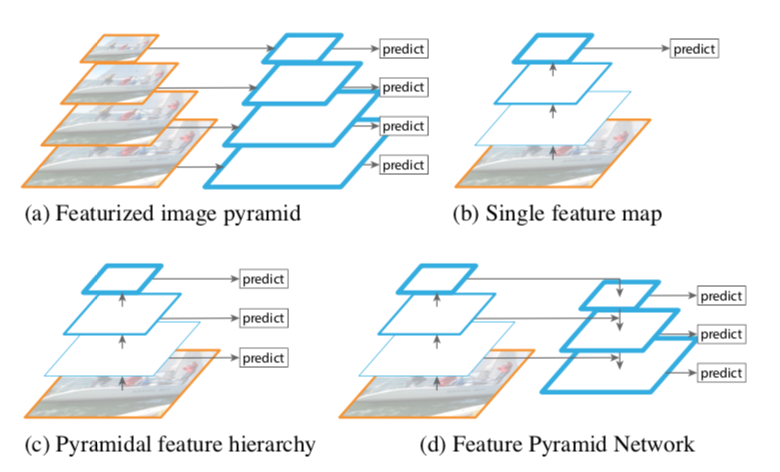

https://arxiv.org/abs/1612.03144

FPN은 특성을 피라미드처럼 쌓아서 사용하는 방식입니다. CNN 백본 네트워크에서는 다양한 레이어의 결과값을 특성 맵(feature map)으로 사용할 수 있습니다. 이때 컨볼루션 연산은 커널을 통해 일정한 영역을 보고 몇 개의 숫자로 요약해 내기 때문에, 입력 이미지를 기준으로 생각하면 입력 이미지와 먼 모델의 뒷쪽의 특성 맵일수록 하나의 "셀(cell)"이 넓은 이미지 영역의 정보를 담고 있고, 입력 이미지와 가까운 앞쪽 레이어의 특성 맵일수록 좁은 범위의 정보를 담고 있습니다. 이를 **receptive field**라고 합니다. 레이어가 깊어질 수록 pooling을 거쳐 넓은 범위의 정보(receptive field)를 갖게 되는 것입니다.

FPN은 백본의 여러 레이어를 한꺼번에 쓰겠다라는데에 의의가 있습니다. SSD가 각 레이어의 특성 맵에서 다양한 크기에 대한 결과를 얻는 방식을 취했다면 RetinaNet에서는 receptive field가 넓은 뒷쪽의 특성 맵을 upsampling(확대)하여 앞단의 특성 맵과 더해서 사용했습니다. 레이어가 깊어질수록 feature map의 $w, h$방향의 receptive field가 넓어지는 것인데, 넓게 보는 것과 좁게 보는 것을 같이 쓰겠다는 목적인 거죠.

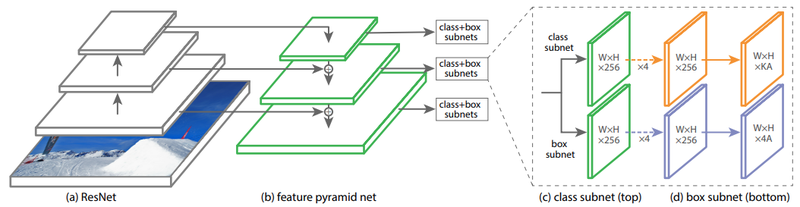

https://arxiv.org/abs/1708.02002

위 그림은 RetinaNet 논문에서 FPN 구조가 어떻게 적용되었는지를 설명하는 그림입니다. RetinaNet에서는 FPN을 통해 $P_3$부터 $P_7$까지의 pyramid level을 생성해 사용합니다. 각 pyramid level은 256개의 채널로 이루어지게 됩니다. 이를 통해 Classification Subnet과 Box Regression Subnet 2개의 Subnet을 구성하게 되는데, Anchor 갯수를 $A$라고 하면 최종적으로 **
\Subnet**은 $K$개 class에 대해 $KA$개 채널을, **Box Regression Subnet**은 4A개 채널을 사용하게 됩니다.



# 데이터 준비

## 데이터 파이프 라인
---
먼저 주어진 KITTI 데이터를 학습에 맞는 형태로 바꾸어 주어야 합니다. 이때 사용할 데이터 파이프라인을 구축합니다.

데이터 파이프라인은 총 4단계로 이루어집니다.

  1. x와 y좌표 위치 교체
  2. 무작위로 수평 뒤집기(Flip)
  3. 이미지 크기 조정 및 패딩 추가
  4. 좌표계를 [x_min, y_min, x_max, y_max]에서 [x_min, y_min, width, height]으로 수정

독립적인 함수를 각각 작성합니다.

In [8]:
# torchvision KITTI는 bbox를 (x_min, y_min, x_max, y_max) 픽셀 좌표로 제공하므로
# (과거 tfds 버전에서 필요했던) 좌표 축 교환은 전처리 단계에서 필요하지 않습니다.
# 참고용으로 축을 바꾸는 유틸 함수만 남겨둡니다.
def swap_xy(boxes):
    return torch.stack([boxes[:, 1], boxes[:, 0], boxes[:, 3], boxes[:, 2]], dim=-1)

print("슝=3")

슝=3


In [9]:
def random_flip_horizontal(image, boxes):
    # image: [C, H, W] 텐서, boxes: [N, 4] (x_min, y_min, x_max, y_max) 픽셀
    if torch.rand(1).item() > 0.5:
        _, _, width = image.shape
        image = TF.hflip(image)
        boxes = torch.stack(
            [width - boxes[:, 2], boxes[:, 1], width - boxes[:, 0], boxes[:, 3]], dim=-1
        )
    return image, boxes

print("슝=3")

슝=3


이미지 크기를 바꿀 때는 고려할 점이 있습니다. 이미지의 비율은 그대로 유지되어야 하고, 이미지의 최대/최소 크기도 제한해야 하거든요. 또 이미지의 크기를 바꾼 후에도 최종적으로 모델에 입력되는 이미지의 크기는 `stride`의 배수가 되도록 만들 거예요.

예를 들어 600x720 크기의 이미지가 있다면 800x960 크기로 바꿀 수 있습니다. 여기에 `stride`를 128로 놓아 800x960 크기의 이미지에 패딩을 더해 896x1024 크기의 이미지로 모델에 입력하겠다는 이야깁니다. 모델에 입력되는 이미지에는 검정 테두리가 있겠군요!

실제로 입력할 이미지를 어떻게 바꿀지는 `min_side`, `max_side`, `min_side_range`, `stride`등에 의해 결정돼요. 그리고 학습이 완료된 모델을 사용할 때는 입력할 이미지를 다양한 크기로 바꿀 필요는 없으니 분기처리를 해줍니다.

In [26]:
def resize_and_pad_image(image, training=True):
    min_side = 800.0
    max_side = 2100
    min_side_range = [640, 1024]
    stride = 128.0

    image_shape = torch.tensor(image.shape[-2:], dtype=torch.float32)  # [H, W]
    if training:
        min_side = torch.empty(1).uniform_(min_side_range[0], min_side_range[1]).item()
    ratio = min_side / torch.min(image_shape)
    if ratio * torch.max(image_shape) > max_side:
        ratio = max_side / torch.max(image_shape)
    new_shape = ratio * image_shape
    new_size = [int(new_shape[0].round().item()), int(new_shape[1].round().item())]  # [H', W']
    image = TF.resize(image, new_size)

    padded = (torch.ceil(new_shape / stride) * stride).int().tolist()
    pad_h = padded[0] - new_size[0]
    pad_w = padded[1] - new_size[1]
    image = TF.pad(image, [0, 0, pad_w, pad_h])  # (left, top, right, bottom)
    return image, torch.tensor(new_size, dtype=torch.float32), float(ratio)

print("슝=3")

슝=3


In [11]:
def convert_to_xywh(boxes):
    return torch.cat(
        [(boxes[..., :2] + boxes[..., 2:]) / 2.0,
         boxes[..., 2:] - boxes[..., :2]],
        dim=-1
    )

print("슝=3")

슝=3


이제 준비된 함수들을 연결해 줍니다.

In [12]:
def preprocess_data(image, boxes, class_ids):
    # image: [C, H, W] 텐서(0~1), boxes: [N, 4] (x_min, y_min, x_max, y_max) 픽셀
    image, boxes = random_flip_horizontal(image, boxes)
    image, _, ratio = resize_and_pad_image(image)

    boxes = boxes * ratio                 # 이미지 리사이즈 비율만큼 박스도 함께 스케일
    boxes = convert_to_xywh(boxes)        # (x_min,y_min,x_max,y_max) -> (cx, cy, w, h)
    return image, boxes, class_ids

print("슝=3")

슝=3


## 인코딩
---
One stage detector에서는 Anchor Box라는 정해져 있는 위치, 크기, 비율 중에 하나로 물체의 위치가 결정됩니다. 그래서 기본적으로 Anchor Box를 생성해줘야 합니다. Anchor Box로 생성되는 것은 물체 위치 후보라고 생각하면 됩니다. 물체 위치를 주관식이 아닌 객관식으로 풀게 하는 겁니다.

예를 들어 100개의 Anchor Box를 생성했다고 가정하면 이미 만들어진 100개의 Anchor Box에 해당하지 않는 위치, 크기, 비율에 물체가 있을 수 없습니다. 100개의 Anchor Box중 가장 근접한 하나가 선택이 되겠죠. 이렇게 선택된 Anchor Box를 기초로 정확한 위치를 찾아냅니다. 추가로 Anchor Box로부터 상하좌우로 떨어진 정도, 가로 세로의 크기 차이를 미세하게 찾아내죠. 게다가 Anchor Box가 촘촘하게 겹치도록 생성되기 때문에 물체를 잘 찾아낼 수 있습니다.

또, RetinaNet에서는 FPN을 사용하기 때문에 Anchor Box가 더 많이 필요합니다. FPN의 각 층마다 Anchor Box가 필요하기 때문입니다. RetinaNet의 FPN에서 pyramid level은 개수가 미리 약속되어 있기 때문에 각 level에서 만들어지는 Anchor Box도 약속되어 있습니다.

여기서는 논문과 같은 형태로 Anchor Box를 생성합니다.

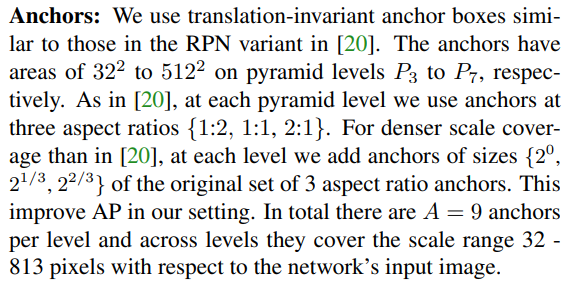

https://arxiv.org/pdf/1708.02002.pdf

In [13]:
class AnchorBox:
    def __init__(self):
        self.aspect_ratios = [0.5, 1.0, 2.0]
        self.scales = [2 ** x for x in [0, 1 / 3, 2 / 3]]

        self._num_anchors = len(self.aspect_ratios) * len(self.scales)
        self._strides = [2 ** i for i in range(3, 8)]
        self._areas = [x ** 2 for x in [32.0, 64.0, 128.0, 256.0, 512.0]]
        self._anchor_dims = self._compute_dims()
        # 같은 입력 크기에 대한 앵커는 매번 동일하므로 캐싱합니다.
        # (KITTI는 전처리 후 모든 이미지가 512x1408로 고정되어 캐시 적중률이 100%입니다.)
        self._anchor_cache = {}

    def _compute_dims(self):
        anchor_dims_all = []
        for area in self._areas:
            anchor_dims = []
            for ratio in self.aspect_ratios:
                anchor_height = torch.sqrt(torch.tensor(area, dtype=torch.float32) / torch.tensor(ratio, dtype=torch.float32))
                anchor_width = torch.tensor(area, dtype=torch.float32) / anchor_height
                dims = torch.stack([anchor_width, anchor_height], dim=-1).view(1, 1, 2)
                for scale in self.scales:
                    anchor_dims.append(scale * dims)
            anchor_dims_all.append(torch.stack(anchor_dims, dim=-2))  # [1,1,9,2]
        return anchor_dims_all

    def _get_anchors(self, feature_height, feature_width, level):
        rx = torch.arange(feature_width, dtype=torch.float32) + 0.5
        ry = torch.arange(feature_height, dtype=torch.float32) + 0.5
        # TF의 tf.meshgrid는 기본이 'xy' 인덱싱이므로 동일하게 맞춰줍니다.
        cx, cy = torch.meshgrid(rx, ry, indexing='xy')          # [feature_height, feature_width]
        centers = torch.stack([cx, cy], dim=-1) * self._strides[level - 3]
        centers = centers.unsqueeze(-2)
        centers = centers.repeat(1, 1, self._num_anchors, 1)
        dims = self._anchor_dims[level - 3].repeat(feature_height, feature_width, 1, 1)
        anchors = torch.cat([centers, dims], dim=-1)
        return anchors.view(feature_height * feature_width * self._num_anchors, 4)

    def get_anchors(self, image_height, image_width):
        key = (int(image_height), int(image_width))
        if key in self._anchor_cache:
            return self._anchor_cache[key]
        anchors = [
            self._get_anchors(
                int(image_height / 2 ** i),
                int(image_width / 2 ** i),
                i,
            )
            for i in range(3, 8)
        ]
        result = torch.cat(anchors, dim=0)
        self._anchor_cache[key] = result
        return result

print('슝=3')

슝=3


이제 Anchor Box를 생성했으니 입력할 데이터를 Anchor Box에 맞게 변형해줘야 합니다.

데이터 원본의 bbox는 주관식 정답이라고 생각하면 됩니다. 하지만 모델은 객관식으로 문제를 풀어야 하기 때문에 주관식 정답을 가장 가까운 객관식 정답으로 바꿔줘야 모델을 학습시킬 수 있습니다.

그럼 어떻게 주관식 정답을 객관식 정답으로 바꿀 수 있을까요? 여기에서 IoU를 사용합니다.

IoU가 높은지 낮은지에 따라 Anchor Box가 정답인지 오답인지 체크해 두는 것이죠. 그러니 IoU를 계산할 수 있는 함수를 만듭니다.

In [14]:
def convert_to_corners(boxes):
    return torch.cat(
        [boxes[..., :2] - boxes[..., 2:] / 2.0, boxes[..., :2] + boxes[..., 2:] / 2.0],
        dim=-1,
    )

def compute_iou(boxes1, boxes2):
    boxes1_corners = convert_to_corners(boxes1)
    boxes2_corners = convert_to_corners(boxes2)
    lu = torch.maximum(boxes1_corners[:, None, :2], boxes2_corners[:, :2])
    rd = torch.minimum(boxes1_corners[:, None, 2:], boxes2_corners[:, 2:])
    intersection = torch.maximum(torch.tensor(0.0), rd - lu)
    intersection_area = intersection[:, :, 0] * intersection[:, :, 1]
    boxes1_area = boxes1[:, 2] * boxes1[:, 3]
    boxes2_area = boxes2[:, 2] * boxes2[:, 3]
    union_area = torch.maximum(
        boxes1_area[:, None] + boxes2_area - intersection_area, torch.tensor(1e-8)
    )
    return torch.clamp(intersection_area / union_area, min=0.0, max=1.0)

print('슝=3')

슝=3


이제 실제 라벨을 Anchor Box에 맞춰주는 클래스를 만들어 봅시다. 위에서 작성한 `compute_iou` 함수를 이용해서 IoU를 구하고 그 IoU를 기준으로 물체에 해당하는 Anchor Box와 배경이 되는 Anchor Box를 지정해 줍니다. 그리고 그 Anchor Box와 실제 Bounding Box의 미세한 차이를 계산합니다. 상하좌우의 차이, 가로세로 크기의 차이를 기록해 두는데 가로세로 크기는 로그를 사용해서 기록해 둡니다.

>이 과정에서 `variance`가 등장하는데 관례적으로 Anchor Box를 사용할 때 등장합니다.  
어디에도 정확한 이유가 등장하지는 않지만 상하좌우의 차이에는 0.1, 가로세로 크기의 차이에는 0.2를 사용합니다.  
이와 관련하여 통계적 추정치를 계산할 때 분산으로 나눠주는 것 때문이라는 의견이 있습니다.

이 과정은 마치 데이터를 훈련이 가능한 형식으로 encode하는 것 같으니 LabelEncoder라는 이름으로 클래스를 만들었습니다.

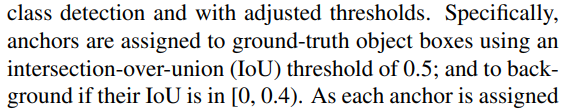

[IoU가 0.5보다 높으면 물체, 0.4보다 낮으면 배경입니다]

 https://arxiv.org/pdf/1708.02002.pdf

In [15]:
class LabelEncoder:

    def __init__(self):
        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor([0.1, 0.1, 0.2, 0.2], dtype=torch.float32)

    def _match_anchor_boxes(self, anchor_boxes, gt_boxes, match_iou=0.5, ignore_iou=0.4):
        iou_matrix = compute_iou(anchor_boxes, gt_boxes)
        max_iou, matched_gt_idx = torch.max(iou_matrix, dim=1)
        positive_mask = (max_iou >= match_iou).float()
        negative_mask = max_iou < ignore_iou
        ignore_mask = (~((max_iou >= match_iou) | negative_mask)).float()
        return matched_gt_idx, positive_mask, ignore_mask

    def _compute_box_target(self, anchor_boxes, matched_gt_boxes):
        box_target = torch.cat(
            [
                (matched_gt_boxes[:, :2] - anchor_boxes[:, :2]) / anchor_boxes[:, 2:],
                torch.log(matched_gt_boxes[:, 2:] / anchor_boxes[:, 2:]),
            ],
            dim=-1,
        )
        return box_target / self._box_variance

    def _encode_sample(self, image_shape, gt_boxes, cls_ids):
        # image_shape: (H, W)
        anchor_boxes = self._anchor_box.get_anchors(image_shape[0], image_shape[1])
        # 객체가 없는 이미지는 모든 앵커를 배경(-1)으로 처리
        if gt_boxes.numel() == 0:
            box_target = torch.zeros_like(anchor_boxes)
            cls_target = torch.full((anchor_boxes.shape[0], 1), -1.0)
            return torch.cat([box_target, cls_target], dim=-1)

        cls_ids = cls_ids.float()
        matched_gt_idx, positive_mask, ignore_mask = self._match_anchor_boxes(anchor_boxes, gt_boxes)
        matched_gt_boxes = gt_boxes[matched_gt_idx]
        box_target = self._compute_box_target(anchor_boxes, matched_gt_boxes)
        matched_gt_cls_ids = cls_ids[matched_gt_idx]
        cls_target = torch.where(positive_mask != 1.0, torch.tensor(-1.0), matched_gt_cls_ids)
        cls_target = torch.where(ignore_mask == 1.0, torch.tensor(-2.0), cls_target)
        cls_target = cls_target.unsqueeze(-1)
        return torch.cat([box_target, cls_target], dim=-1)

    def encode_batch(self, batch_images, gt_boxes, cls_ids):
        # batch_images: [N, C, H, W] (모두 같은 크기로 패딩됨)
        N, _, H, W = batch_images.shape
        labels = [self._encode_sample((H, W), gt_boxes[i], cls_ids[i]) for i in range(N)]

        # ImageNet 채널별 정규화 (ResNet backbone 규격)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        batch_images = (batch_images - mean) / std

        return batch_images, torch.stack(labels, dim=0)

print('슝=3')

슝=3


이제 데이터를 모델이 학습 가능한 형태로 바꿔 줄 수 있게 되었으니 모델을 만들러 가봅시다.

# 모델 작성

## Feature Pyramid
---
앞서 설명했듯이 RetinaNet에서는 FPN(Feature Pyramid Network)를 사용합니다. 완전히 동일한 것은 아니고 약간 수정해서 사용했습니다. 자세한 설명은 아래에 나와있네요.

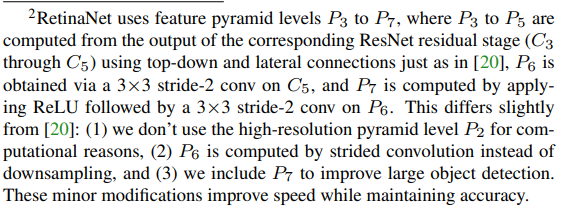

[FPN을 약간 수정합니다]  
https://arxiv.org/pdf/1708.02002.pdf

In [16]:
class FeaturePyramid(nn.Module):

    def __init__(self, backbone):
        super(FeaturePyramid, self).__init__()
        self.backbone = backbone
        # ResNet50의 C3/C4/C5 채널 수는 각각 512 / 1024 / 2048 입니다.
        self.conv_c3_1x1 = nn.Conv2d(512, 256, 1, 1, padding=0)
        self.conv_c4_1x1 = nn.Conv2d(1024, 256, 1, 1, padding=0)
        self.conv_c5_1x1 = nn.Conv2d(2048, 256, 1, 1, padding=0)
        self.conv_c3_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c4_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c5_3x3 = nn.Conv2d(256, 256, 3, 1, padding=1)
        self.conv_c6_3x3 = nn.Conv2d(2048, 256, 3, 2, padding=1)   # C5(2048ch)로부터 P6 생성
        self.conv_c7_3x3 = nn.Conv2d(256, 256, 3, 2, padding=1)
        self.upsample_2x = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, images):
        c3_output, c4_output, c5_output = self.backbone(images)
        p3_output = self.conv_c3_1x1(c3_output)
        p4_output = self.conv_c4_1x1(c4_output)
        p5_output = self.conv_c5_1x1(c5_output)
        p4_output = p4_output + self.upsample_2x(p5_output)
        p3_output = p3_output + self.upsample_2x(p4_output)
        p3_output = self.conv_c3_3x3(p3_output)
        p4_output = self.conv_c4_3x3(p4_output)
        p5_output = self.conv_c5_3x3(p5_output)
        p6_output = self.conv_c6_3x3(c5_output)
        p7_output = self.conv_c7_3x3(NF.relu(p6_output))
        return p3_output, p4_output, p5_output, p6_output, p7_output

print('슝=3')

슝=3


Object Detection의 라벨은 class와 box로 이루어지므로 각각을 추론하는 부분이 필요합니다. 그것을 head라고 부르기도 합니다. Backbone에 해당하는 네트워크와 FPN을 통해 pyramid layer가 추출되고 나면 그 feature들을 바탕으로 class를 예상하고, box도 예상합니다. class와 box가 모두 맞을 수도, class와 box 중 하나만 맞을 수도, 둘 다 틀릴 수도 있겠죠? class를 예측하는 head와 box를 예측하는 head가 별도로 존재한다는 것이 중요합니다.

그래서 각각의 head를 만들어 줍니다. head부분은 유사한 형태로 만들 수 있으니 `build_head`라는 함수를 하나만 만들고 두 번 호출하면 될 것 같네요.

In [17]:
def build_head(output_filters, bias_init):
    layers = []
    for _ in range(4):
        conv = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        nn.init.normal_(conv.weight, mean=0.0, std=0.01)
        nn.init.zeros_(conv.bias)
        layers.append(conv)
        layers.append(nn.ReLU())

    out_conv = nn.Conv2d(256, output_filters, kernel_size=3, stride=1, padding=1)
    nn.init.normal_(out_conv.weight, mean=0.0, std=0.01)
    if bias_init == "zeros":
        nn.init.zeros_(out_conv.bias)
    else:
        nn.init.constant_(out_conv.bias, float(bias_init))
    layers.append(out_conv)

    return nn.Sequential(*layers)

print('슝=3')

슝=3


우리가 만들 RetinaNet의 backbone은 ResNet50입니다. FPN에 이용할 수 있도록 중간 레이어도 output으로 연결해 줍니다.

In [18]:
class Backbone(nn.Module):
    """ResNet50에서 C3, C4, C5 특성 맵을 뽑아 반환하는 backbone."""
    def __init__(self):
        super(Backbone, self).__init__()
        base = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2   # C3 (stride 8,  512ch)
        self.layer3 = base.layer3   # C4 (stride 16, 1024ch)
        self.layer4 = base.layer4   # C5 (stride 32, 2048ch)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        c3 = self.layer2(x)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)
        return c3, c4, c5

def get_backbone():
    return Backbone()

print('슝=3')

슝=3


이제 RetinaNet을 완성해 봅시다. Backbone + FPN + classification용 head + box용 head 입니다.

In [19]:
class RetinaNet(nn.Module):
    def __init__(self, num_classes, backbone):
        super(RetinaNet, self).__init__()
        self.fpn = FeaturePyramid(backbone)
        self.num_classes = num_classes

        prior_probability = -torch.log(torch.tensor((1 - 0.01) / 0.01))
        self.cls_head = build_head(9 * num_classes, prior_probability)
        self.box_head = build_head(9 * 4, "zeros")

    def forward(self, image):
        features = self.fpn(image)
        N = image.size(0)
        cls_outputs = []
        box_outputs = []
        for feature in features:
            # [N, C, H, W] -> [N, H, W, C] -> [N, H*W*9, 4 or num_classes]
            # 앵커 순서(H, W, anchor)와 일치시키기 위해 permute 후 reshape 합니다.
            box_outputs.append(self.box_head(feature).permute(0, 2, 3, 1).reshape(N, -1, 4))
            cls_outputs.append(self.cls_head(feature).permute(0, 2, 3, 1).reshape(N, -1, self.num_classes))
        cls_outputs = torch.cat(cls_outputs, dim=1)
        box_outputs = torch.cat(box_outputs, dim=1)
        return torch.cat([box_outputs, cls_outputs], dim=-1)

print('슝=3')

슝=3


이제 모델을 준비했고, Loss에 대한 준비를 해봅시다.

RetinaNet에서는 Focal Loss를 사용하는데요. Box Regression에는 사용하지 않고 Classification Loss를 계산하는데만 사용됩니다. Box Regression에는 Smooth L1 Loss를 사용했네요.

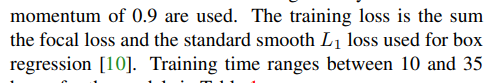

[Focal Loss + Smooth L1 Loss]  
https://arxiv.org/pdf/1708.02002.pdf

Smooth L1 Loss을 사용하는 Box Regression에는 `delta`를 기준으로 계산이 달라지고, Focal Loss를 사용하는 Classification에서는 `alpha`와 `gamma`를 사용해서 물체일 때와 배경일 때의 식이 달라지는 점에 주의하세요!

In [20]:
class RetinaNetBoxLoss(nn.Module):
    def __init__(self, delta):
        super(RetinaNetBoxLoss, self).__init__()
        self._delta = delta

    def forward(self, y_true, y_pred):
        difference = y_true - y_pred
        absolute_difference = torch.abs(difference)
        squared_difference = difference ** 2
        loss = torch.where(
            absolute_difference < self._delta,
            0.5 * squared_difference,
            absolute_difference - 0.5 * self._delta,
        )
        return torch.sum(loss, dim=-1)

class RetinaNetClassificationLoss(nn.Module):
    def __init__(self, alpha, gamma):
        super(RetinaNetClassificationLoss, self).__init__()
        self._alpha = alpha
        self._gamma = gamma

    def forward(self, y_true, y_pred):
        cross_entropy = NF.binary_cross_entropy_with_logits(y_pred, y_true, reduction='none')
        probs = torch.sigmoid(y_pred)
        alpha = torch.where(y_true == 1.0, torch.tensor(self._alpha), torch.tensor(1.0 - self._alpha))
        pt = torch.where(y_true == 1.0, probs, 1 - probs)
        loss = alpha * torch.pow(1.0 - pt, self._gamma) * cross_entropy
        return torch.sum(loss, dim=-1)

class RetinaNetLoss(nn.Module):
    def __init__(self, num_classes=8, alpha=0.25, gamma=2.0, delta=1.0):
        super(RetinaNetLoss, self).__init__()
        self._clf_loss = RetinaNetClassificationLoss(alpha, gamma)
        self._box_loss = RetinaNetBoxLoss(delta)
        self._num_classes = num_classes

    def forward(self, y_true, y_pred):
        box_labels = y_true[:, :, :4]
        box_predictions = y_pred[:, :, :4]
        cls_predictions = y_pred[:, :, 4:]

        cls_ids = y_true[:, :, 4]
        positive_mask = (cls_ids > -1.0).float()     # 물체(양성) 앵커
        ignore_mask = (cls_ids == -2.0).float()       # 무시(-2) 앵커

        # one_hot은 음수 인덱스를 허용하지 않으므로 배경/무시(-1,-2)는 0으로 clamp 후 마스킹
        cls_target_idx = cls_ids.clamp(min=0).long()
        cls_labels = NF.one_hot(cls_target_idx, num_classes=self._num_classes).float()
        cls_labels = cls_labels * positive_mask.unsqueeze(-1)   # 배경 앵커는 전부 0 (focal loss 규격)

        clf_loss = self._clf_loss(cls_labels, cls_predictions)
        box_loss = self._box_loss(box_labels, box_predictions)

        clf_loss = torch.where(ignore_mask == 1.0, torch.zeros_like(clf_loss), clf_loss)
        box_loss = torch.where(positive_mask == 1.0, box_loss, torch.zeros_like(box_loss))

        normalizer = torch.clamp(positive_mask.sum(dim=-1), min=1.0)
        clf_loss = clf_loss.sum(dim=-1) / normalizer
        box_loss = box_loss.sum(dim=-1) / normalizer

        return (clf_loss + box_loss).mean()

print('슝=3')

슝=3


이제 모든 준비가 끝났습니다. 모델 학습을 할 수 있겠네요!

# 모델 학습

앞에서 만들어 놓은 클래스와 함수를 이용해서 모델을 조립하고 학습시켜 봅시다.

In [21]:
num_classes = 8
batch_size = 2

resnet50_backbone = get_backbone()
loss_fn = RetinaNetLoss(num_classes)
model = RetinaNet(num_classes, resnet50_backbone)

print('슝=3')

슝=3


모델은 매우 간단하게 만들어 졌네요.

다음으로 Learning Rate입니다. 논문에서는 8개의 GPU를 사용했기 때문에 우리 환경과는 맞지 않아요. 그래서 Learning Rate를 적절히 바꿔줍니다.

Optimizer는 동일하게 SGD를 사용합니다.

In [22]:
# 논문은 GPU 8장 기준이므로 학습률을 우리 환경에 맞게 낮춰 사용합니다.
learning_rates = [2.5e-06, 0.000625, 0.00125, 0.0025, 0.00025, 2.5e-05]
learning_rate_boundaries = [125, 250, 500, 240000, 360000]   # step 단위 (warmup 500 step)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rates[0], momentum=0.9)

def lr_lambda(step):
    """누적 step 에 따라 base_lr(learning_rates[0]) 대비 배율을 반환합니다."""
    for i, boundary in enumerate(learning_rate_boundaries):
        if step < boundary:
            return learning_rates[i] / learning_rates[0]
    return learning_rates[-1] / learning_rates[0]

scheduler = LambdaLR(optimizer, lr_lambda)
print('슝=3')

슝=3


이제 데이터 전처리를 위한 파이프라인도 만들어 줍니다.

In [23]:
label_encoder = LabelEncoder()

class KITTIDetection(Dataset):
    """torchvision KITTI를 감싸 (image_tensor, boxes_xywh, class_ids)를 반환하는 Dataset."""
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        image, target = self.base[idx]          # PIL image, list of dict
        boxes, class_ids = parse_kitti_target(target)
        image = TF.to_tensor(image)             # [3, H, W], 0~1
        image, boxes, class_ids = preprocess_data(image, boxes, class_ids)
        return image, boxes, class_ids

def make_collate_fn(label_encoder):
    """배치 이미지를 공통 크기로 패딩한 뒤, LabelEncoder로 라벨을 인코딩합니다.
    (앵커 수를 이미지 크기에 맞추기 위해 인코딩은 패딩 후에 수행해야 합니다.)"""
    def collate_fn(batch):
        images, boxes, cls_ids = zip(*batch)
        max_h = max(img.shape[1] for img in images)
        max_w = max(img.shape[2] for img in images)

        padded = []
        for img in images:
            pad_h = max_h - img.shape[1]
            pad_w = max_w - img.shape[2]
            padded.append(NF.pad(img, (0, pad_w, 0, pad_h)))   # (left,right,top,bottom)
        images = torch.stack(padded)

        images, labels = label_encoder.encode_batch(images, list(boxes), list(cls_ids))
        return images, labels
    return collate_fn

# 학습/검증 분할 (예시용)
full_dataset = KITTIDetection(kitti_train)
val_size = max(1, int(len(full_dataset) * 0.1))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

collate_fn = make_collate_fn(label_encoder)
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
    collate_fn=collate_fn, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False, drop_last=True,
    collate_fn=collate_fn, num_workers=NUM_WORKERS
)

print('슝=3')

슝=3


In [30]:
# 전처리 결과 크기 확인
for ms in [640, 800, 1024]:
    img = torch.zeros(3, 375, 1242)
    out, new_size, ratio = resize_and_pad_image(img, training=False)
    print(f"min_side={ms:5d} -> resized {new_size.tolist()}  padded {list(out.shape[-2:])}  ratio={ratio:.4f}")

n_anchors = AnchorBox().get_anchors(512, 1408).shape[0]
print(f"\n입력 크기 512x1408 기준 앵커 개수: {n_anchors:,}")

min_side=  640 -> resized [634.0, 2100.0]  padded [640, 2176]  ratio=1.6908
min_side=  800 -> resized [634.0, 2100.0]  padded [640, 2176]  ratio=1.6908
min_side= 1024 -> resized [634.0, 2100.0]  padded [640, 2176]  ratio=1.6908

입력 크기 512x1408 기준 앵커 개수: 135,036


### 학습

In [32]:
import time
from tqdm.auto import tqdm

EPOCHS      = 5
USE_AMP     = True
LOG_EVERY   = 50
VAL_BATCHES = 200     # 검증은 앞 200배치만 사용

model.to(device)
history = {"step": [], "loss": [], "val_epoch": [], "val_loss": []}
global_step = 0

for epoch in range(EPOCHS):
    # ---------------- train ----------------
    model.train()
    running, t0 = 0.0, time.time()
    pbar = tqdm(train_loader, desc=f"epoch {epoch + 1}/{EPOCHS}")
    for step, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        if USE_AMP and device.type == 'cuda':
            with torch.autocast('cuda', dtype=torch.bfloat16):
                preds = model(images)
            loss = loss_fn(labels, preds.float())
        else:
            loss = loss_fn(labels, model(images))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)   # 초기 발산 방지
        optimizer.step()
        scheduler.step()

        running += loss.item()
        global_step += 1
        if step % LOG_EVERY == 0:
            avg = running / (step + 1)
            history["step"].append(global_step)
            history["loss"].append(avg)
            pbar.set_postfix(loss=f"{avg:.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

    train_loss = running / max(1, len(train_loader))

    # ---------------- validation ----------------
    model.eval()
    vsum, vcnt = 0.0, 0
    with torch.no_grad():
        for i, (images, labels) in enumerate(val_loader):
            if i >= VAL_BATCHES:
                break
            images, labels = images.to(device), labels.to(device)
            vsum += loss_fn(labels, model(images).float()).item()
            vcnt += 1
    val_loss = vsum / max(1, vcnt)
    history["val_epoch"].append(epoch + 1)
    history["val_loss"].append(val_loss)

    print(f"[epoch {epoch + 1}/{EPOCHS}] train {train_loss:.4f} | "
          f"val {val_loss:.4f} | {time.time() - t0:.0f}s")

    # ---------------- checkpoint ----------------
    ckpt = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": train_loss,
        "val_loss": val_loss,
    }
    torch.save(ckpt, os.path.join(CKPT_PATH, f"weights_epoch_{epoch + 1}.pth"))
    torch.save(ckpt, os.path.join(CKPT_PATH, "latest_checkpoint.pth"))

print("학습 완료. 체크포인트:", CKPT_PATH)

epoch 1/5:   0%|          | 0/3366 [00:00<?, ?it/s]

[epoch 1/5] train 1.6063 | val 0.9444 | 1365s


epoch 2/5:   0%|          | 0/3366 [00:00<?, ?it/s]

[epoch 2/5] train 0.7477 | val 0.7708 | 1305s


epoch 3/5:   0%|          | 0/3366 [00:00<?, ?it/s]

[epoch 3/5] train 0.5706 | val 0.6178 | 1301s


epoch 4/5:   0%|          | 0/3366 [00:00<?, ?it/s]

KeyboardInterrupt: 

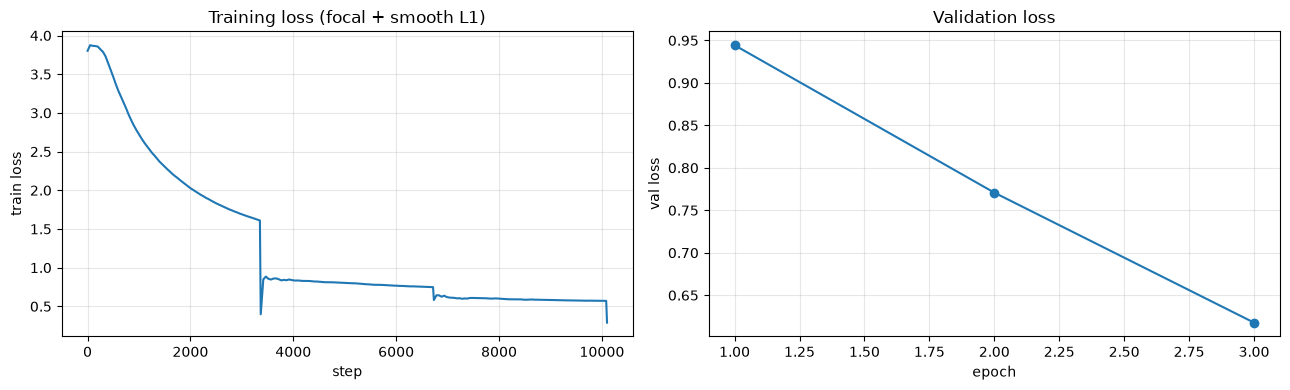

In [33]:
# 학습 곡선 시각화
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(history["step"], history["loss"])
ax[0].set_xlabel("step"); ax[0].set_ylabel("train loss")
ax[0].set_title("Training loss (focal + smooth L1)")
ax[0].grid(alpha=0.3)

ax[1].plot(history["val_epoch"], history["val_loss"], marker="o")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val loss")
ax[1].set_title("Validation loss")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 결과 확인하기

학습된 모델을 불러옵시다.

In [34]:
# 학습된 모델 불러오기
model = RetinaNet(num_classes, get_backbone()).to(device)

checkpoint_path = os.path.join(CKPT_PATH, 'latest_checkpoint.pth')

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"체크포인트 로드 완료: {checkpoint_path}")
    print(f"  epoch={checkpoint['epoch']}  train_loss={checkpoint['loss']:.4f}")
else:
    print(f"체크포인트가 없습니다: {checkpoint_path}")
    print("  위의 학습 셀을 먼저 실행해 주세요.")

print('슝=3')

체크포인트 로드 완료: C:\Aiffel\AIFFEL_quest_rs\GoingDeeper\Deep02\data\checkpoints\latest_checkpoint.pth
  epoch=3  train_loss=0.5706
슝=3


모델의 추론 결과를 처리할 함수를 레이어 형식으로 만들어 줍니다. 논문에서는 1000개의 후보를 골라 처리했지만 우리는 100개의 후보만 골라 처리하도록 합시다. 나머지 설정은 논문과 동일하게 해볼게요.

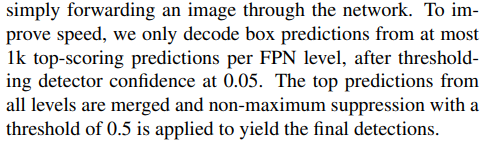

[0.05보다 높은 box 1000개를 골라 0.5 NMS를 진행합니다]

 https://arxiv.org/pdf/1708.02002.pdf

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import nms  # PyTorch에서 NMS 기능 제공

class DecodePredictions(nn.Module):

    def __init__(
        self,
        num_classes=8,
        confidence_threshold=0.05,
        nms_iou_threshold=0.5,
        max_detections_per_class=100,
        max_detections=100,
        box_variance=[0.1, 0.1, 0.2, 0.2]
    ):
        super(DecodePredictions, self).__init__()
        self.num_classes = num_classes
        self.confidence_threshold = confidence_threshold
        self.nms_iou_threshold = nms_iou_threshold
        self.max_detections_per_class = max_detections_per_class
        self.max_detections = max_detections
        self._anchor_box = AnchorBox()
        self._box_variance = torch.tensor(box_variance, dtype=torch.float32)

    def _decode_box_predictions(self, anchor_boxes, box_predictions):
        boxes = box_predictions * self._box_variance
        boxes = torch.cat(
            [
                boxes[:, :, :2] * anchor_boxes[:, :, 2:] + anchor_boxes[:, :, :2],
                torch.exp(boxes[:, :, 2:]) * anchor_boxes[:, :, 2:],
            ],
            dim=-1,
        )
        boxes_transformed = convert_to_corners(boxes)
        return boxes_transformed

    def forward(self, images, predictions):
        image_shape = images.shape
        anchor_boxes = self._anchor_box.get_anchors(image_shape[2], image_shape[3])
        box_predictions = predictions[:, :, :4]
        cls_predictions = torch.sigmoid(predictions[:, :, 4:])
        boxes = self._decode_box_predictions(anchor_boxes[None, ...], box_predictions)
        selected_boxes = []
        selected_scores = []
        selected_classes = []

        for i in range(boxes.shape[0]):
            for class_id in range(self.num_classes):
                class_scores = cls_predictions[i, :, class_id]
                mask = class_scores > self.confidence_threshold
                if mask.sum() == 0:
                    continue
                class_boxes = boxes[i, mask]
                class_scores = class_scores[mask]
                keep = nms(class_boxes, class_scores, self.nms_iou_threshold)
                selected_boxes.append(class_boxes[keep])
                selected_scores.append(class_scores[keep])
                selected_classes.append(torch.full_like(class_scores[keep], class_id, dtype=torch.int64))

        num_detections = len(selected_boxes)
        selected_boxes = torch.cat(selected_boxes, dim=0) if selected_boxes else torch.empty(0, 4)
        selected_scores = torch.cat(selected_scores, dim=0) if selected_scores else torch.empty(0)
        selected_classes = torch.cat(selected_classes, dim=0) if selected_classes else torch.empty(0, dtype=torch.int64)
        num_detections = min(self.max_detections, num_detections)
        selected_boxes = selected_boxes[:num_detections]
        selected_scores = selected_scores[:num_detections]
        selected_classes = selected_classes[:num_detections]

        return selected_boxes, selected_scores, selected_classes

print('슝=3')

슝=3


이제 추론이 가능한 모델을 조립합니다.

In [36]:
# 직접 만든 RetinaNet + DecodePredictions로 '추론 파이프라인'을 조립해봅니다.
# 원시 출력 -> 박스 디코딩 -> NMS 로 이어지는 흐름을 형상(shape)으로 확인합니다.
decoder = DecodePredictions(num_classes=num_classes, confidence_threshold=0.05)
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, 896, 896, device=device)   # model 은 위에서 device 로 올라가 있습니다
    raw = model(dummy).float()                           # [1, num_anchors, 4 + num_classes]
    boxes, scores, classes = decoder(dummy.cpu(), raw.cpu())
print("직접 만든 RetinaNet 추론 조립 확인:",
      tuple(raw.shape), "->", tuple(boxes.shape), tuple(scores.shape), tuple(classes.shape))

# 아래 프로젝트(GO/STOP)에서는 COCO 사전학습 RetinaNet 을 비교용으로 함께 사용합니다.
# person/car 등 COCO 91클래스를 사용합니다.
from torchvision.models.detection import retinanet_resnet50_fpn, RetinaNet_ResNet50_FPN_Weights
weights = RetinaNet_ResNet50_FPN_Weights.COCO_V1
inference_model = retinanet_resnet50_fpn(weights=weights)
inference_model.eval()
COCO_CLASSES = weights.meta["categories"]   # index 0 = __background__
print("사전학습 RetinaNet 준비 완료 — COCO", len(COCO_CLASSES), "classes")

직접 만든 RetinaNet 추론 조립 확인: (1, 150381, 12) -> (4, 4) (4,) (4,)
사전학습 RetinaNet 준비 완료 — COCO 91 classes


모델의 추론 결과를 시각화 할 함수를 만들어 줍니다.

In [37]:
def visualize_detections(
    image, boxes, classes, scores, figsize=(7, 7), linewidth=1, color=[0, 0, 1]
):
    image = np.array(image, dtype=np.uint8)
    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(image)
    ax = plt.gca()
    for box, _cls, score in zip(boxes, classes, scores):
        text = "{}: {:.2f}".format(_cls, float(score))
        x1, y1, x2, y2 = [float(v) for v in box]
        w, h = x2 - x1, y2 - y1
        patch = plt.Rectangle(
            [x1, y1], w, h, fill=False, edgecolor=color, linewidth=linewidth
        )
        ax.add_patch(patch)
        ax.text(
            x1, y1, text,
            bbox={"facecolor": color, "alpha": 0.4},
            clip_box=ax.clipbox, clip_on=True,
        )
    plt.show()
    return ax

print('슝=3')

슝=3


이제 추론시에 입력 데이터를 전처리하기 위한 함수를 만들게요.

학습을 위한 전처리와 추론을 위한 전처리가 다르기 때문에 따로 작성됩니다. 추론을 위한 전처리가 훨씬 간단하네요.

In [38]:
def prepare_image(image):
    # torchvision 검출 모델은 [0,1] 범위의 CxHxW 텐서를 입력으로 받고,
    # 내부에서 리사이즈/정규화를 자동으로 처리합니다.
    if not torch.is_tensor(image):
        image = TF.to_tensor(image)
    return image.unsqueeze(0), 1.0

print('슝=3')

슝=3


이제 모든 것이 준비 되었으니 학습된 결과를 확인합시다!!

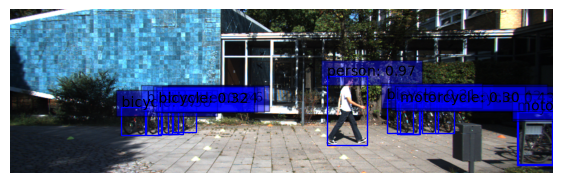

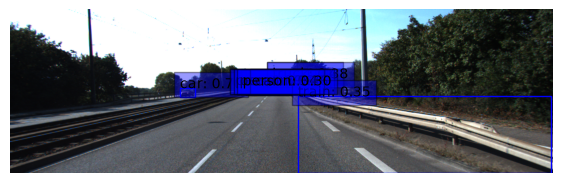

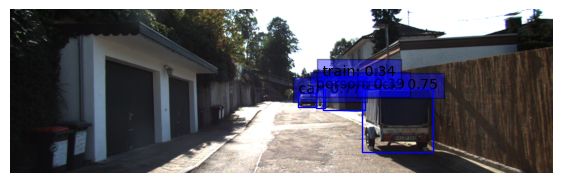

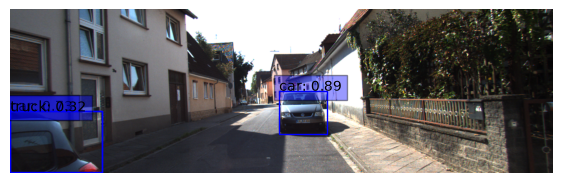

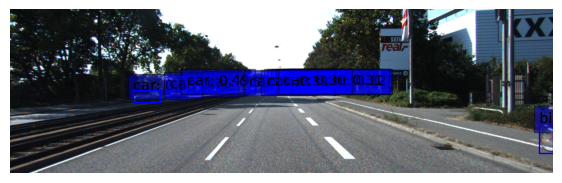

In [39]:
# KITTI 이미지 몇 장을 사전학습 RetinaNet(inference_model)으로 추론해 시각화합니다.
for idx in range(5):
    image, _ = kitti_train[idx]                 # PIL image
    input_image, ratio = prepare_image(image)
    with torch.no_grad():
        detections = inference_model(input_image)[0]

    keep = detections["scores"] > 0.3
    boxes = detections["boxes"][keep] / ratio
    labels = detections["labels"][keep]
    scores = detections["scores"][keep]
    class_names = [COCO_CLASSES[int(l)] for l in labels]

    visualize_detections(image, boxes, class_names, scores)

## 학습한 RetinaNet 으로 검출 결과 시각화하기
---
위 셀은 torchvision의 **COCO 사전학습** RetinaNet 결과입니다.
앞에서 저장한 학습한 체크포인트를 불러와 KITTI 이미지에 대해 다시 시각화합니다.

[0] 검출 1개: ['Pedestrian']


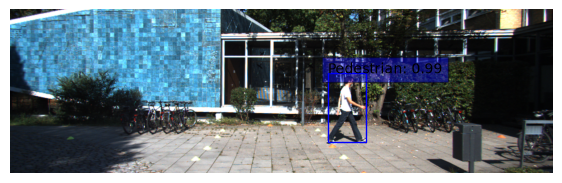

[1] 검출 2개: ['Car', 'Van']


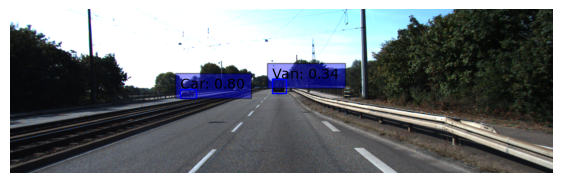

[2] 검출 3개: ['Car']


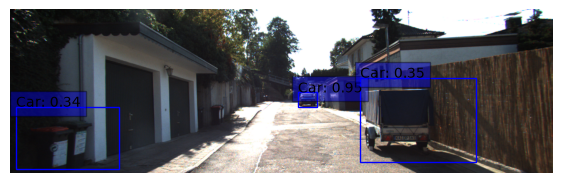

[3] 검출 2개: ['Car']


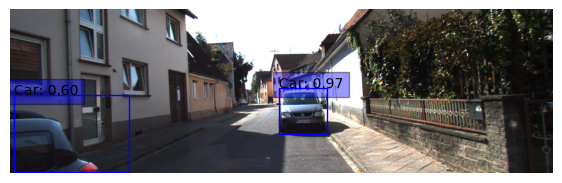

[4] 검출 2개: ['Car']


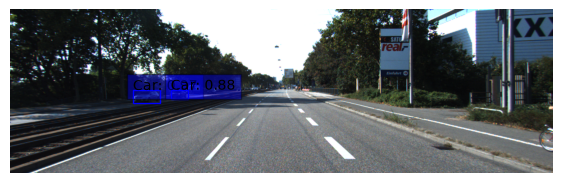

In [40]:
# 학습한 RetinaNet(KITTI 8클래스) 으로 추론 -> 디코딩 -> NMS -> 시각화
@torch.no_grad()
def detect_with_trained_model(pil_image, score_threshold=0.3):
    """학습된 RetinaNet 으로 PIL 이미지 한 장을 검출합니다."""
    image = TF.to_tensor(pil_image)                              # [3,H,W], 0~1
    image, _, ratio = resize_and_pad_image(image, training=False)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    x = ((image - mean) / std).unsqueeze(0).to(device)

    model.eval()
    preds = model(x).float().cpu()                               # 디코더는 CPU 텐서 기준
    boxes, scores, classes = decoder(x.cpu(), preds)

    keep = scores > score_threshold
    boxes = boxes[keep] / ratio                                  # 원본 이미지 좌표로 복원
    scores = scores[keep]
    names = [KITTI_CLASSES[int(c)] for c in classes[keep]]
    return boxes, names, scores


for idx in range(5):
    pil_image, _ = kitti_train[idx]
    boxes, names, scores = detect_with_trained_model(pil_image)
    print(f"[{idx}] 검출 {len(boxes)}개: {sorted(set(names))}")
    visualize_detections(pil_image, boxes, names, scores)

# 프로젝트: 자율주행 보조 시스템 만들기

먼저 주요 라이브러리 버전을 확인해봅시다.

In [38]:
import torch

print(torch.__version__)

2.11.0+cu128


## 1. 자율주행 시스템 만들기
---
위에서 만든 모델을 통해 아래의 조건을 만족하는 함수를 만들어 주세요.

  - 입력으로 이미지 경로를 받습니다.
  - 정지조건에 맞는 경우 "Stop" 아닌 경우 "Go"를 반환합니다.
  - 조건은 다음과 같습니다.
    - 사람이 한 명 이상 있는 경우
    - 차량의 크기(width or height)가 300px이상인 경우

In [41]:
img_path = os.path.join(IMAGE_PATH, 'stop_1.png')

def self_drive_assist(img_path, size_limit=300):
    # 이미지를 읽어 텐서로 변환
    image = Image.open(img_path).convert("RGB")
    input_tensor = transforms.ToTensor()(image).unsqueeze(0)

    # 앞에서 준비한 inference_model(torchvision 사전학습 RetinaNet, COCO 라벨)로 추론
    inference_model.eval()
    with torch.no_grad():
        detections = inference_model(input_tensor)[0]

    # COCO 클래스 인덱스: person=1, bicycle=2, car=3, motorcycle=4, bus=6, truck=8
    PERSON = {1}
    VEHICLES = {2, 3, 4, 6, 8}
    score_threshold = 0.5

    for box, label, score in zip(detections["boxes"], detections["labels"], detections["scores"]):
        if score < score_threshold:
            continue
        label = int(label)
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1
        # 사람이 탐지되면 무조건 정지
        if label in PERSON:
            return "Stop"
        # 차량의 width 또는 height가 size_limit(기본 300px) 이상이면 정지
        if label in VEHICLES and max(w, h) >= size_limit:
            return "Stop"

    return "Go"

print(self_drive_assist(img_path))

Stop


## 2. 자율주행 시스템 평가하기
---
아래 `test_system()` 를 통해서 위에서 만든 함수를 평가해봅시다. 10장에 대해 Go와 Stop을 맞게 반환하는지 확인하고 100점 만점으로 평가해줍니다.

In [42]:
import os

def test_system(func):
    score = 0
    test_set=[
        ("stop_1.png", "Stop"),
        ("stop_2.png", "Stop"),
        ("stop_3.png", "Stop"),
        ("stop_4.png", "Stop"),
        ("stop_5.png", "Stop"),
        ("go_1.png", "Go"),
        ("go_2.png", "Go"),
        ("go_3.png", "Go"),
        ("go_4.png", "Go"),
        ("go_5.png", "Go"),
    ]

    for image_file, answer in test_set:
        image_path = IMAGE_PATH + '/' + image_file
        pred = func(image_path)
        if pred == answer:
            score += 10
    print(f"{score}점입니다.")

test_system(self_drive_assist)

80점입니다.


## 3. 직접 학습한 RetinaNet 으로 교체해보기
---
**torchvision 의 COCO 사전학습 RetinaNet** 을 직접 구현하고 학습시킨 모델로 교체한다.
클래스 체계가 다르므로 판정 대상을 다시 대응시켜야 한다.

| 구분 | COCO (기존) | KITTI (직접 학습) |
|---|---|---|
| 사람 | `person`(1) | `Pedestrian`(3), `Person_sitting`(4), `Cyclist`(5) |
| 차량 | `bicycle`(2), `car`(3), `motorcycle`(4), `bus`(6), `truck`(8) | `Car`(0), `Van`(1), `Truck`(2), `Tram`(6) |


판정 규칙(사람 1명 이상 / 차량 300px 이상)과 `score_threshold=0.5` 는 기존과 동일하게 두었다.

In [43]:
KITTI_PERSON  = {'Pedestrian', 'Person_sitting', 'Cyclist'}
KITTI_VEHICLE = {'Car', 'Van', 'Truck', 'Tram'}


def self_drive_assist_kitti(img_path, size_limit=300, score_threshold=0.5):
    """직접 학습한 RetinaNet(KITTI 8클래스)으로 "Stop"/"Go" 를 판정합니다.

    판정 조건은 기존 self_drive_assist() 와 동일합니다.
      - 사람(Pedestrian/Person_sitting/Cyclist)이 한 명 이상 탐지되면 Stop
      - 차량(Car/Van/Truck/Tram)의 width 또는 height 가 size_limit 이상이면 Stop
    """
    image = Image.open(img_path).convert("RGB")
    boxes, names, scores = detect_with_trained_model(image, score_threshold=score_threshold)

    for box, name in zip(boxes, names):
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1
        if name in KITTI_PERSON:
            return "Stop"
        if name in KITTI_VEHICLE and max(w, h) >= size_limit:
            return "Stop"

    return "Go"


print(self_drive_assist_kitti(os.path.join(IMAGE_PATH, 'stop_1.png')))

Stop


In [44]:
# 10장에 대해 학습 모델이 무엇을 어떤 신뢰도로 검출하는지 확인 (임계값 0.05)
test_files = [f"stop_{i}.png" for i in range(1, 6)] + [f"go_{i}.png" for i in range(1, 6)]

for f in test_files:
    image = Image.open(os.path.join(IMAGE_PATH, f)).convert("RGB")
    boxes, names, scores = detect_with_trained_model(image, score_threshold=0.05)
    print(f"\n=== {f} — 검출 {len(boxes)}개 ===")
    order = torch.argsort(scores, descending=True)[:8]
    for j in order:
        x1, y1, x2, y2 = boxes[j].tolist()
        print(f"   {names[j]:15s} score={scores[j]:.3f}  "
              f"{x2 - x1:6.1f} x {y2 - y1:6.1f}")
    if len(boxes) == 0:
        print("   (검출 없음)")


=== stop_1.png — 검출 4개 ===
   Pedestrian      score=0.960    61.5 x  162.5
   Pedestrian      score=0.504    41.1 x  111.6
   Pedestrian      score=0.183    28.6 x   79.5
   Car             score=0.055   100.1 x   79.9

=== stop_2.png — 검출 6개 ===
   Pedestrian      score=0.979    83.0 x  156.2
   Pedestrian      score=0.308    31.2 x   77.4
   Pedestrian      score=0.197    55.1 x  121.7
   Car             score=0.109    89.2 x  155.9
   Pedestrian      score=0.098    26.3 x   63.8
   Truck           score=0.081    94.7 x  165.5

=== stop_3.png — 검출 8개 ===
   Car             score=0.989   290.3 x  167.5
   Car             score=0.909   115.4 x   47.2
   Car             score=0.195    59.7 x   59.1
   Car             score=0.192   125.9 x   56.3
   Car             score=0.116    57.2 x   91.9
   Car             score=0.096    52.3 x   40.8
   Car             score=0.089   214.0 x  123.3
   Car             score=0.083    86.0 x   46.5

=== stop_4.png — 검출 8개 ===
   Car             score

### 두 모델 비교 채점

In [45]:
# 동일한 test_system 으로 두 모델을 나란히 채점합니다.
print("[COCO 사전학습 RetinaNet]")
test_system(self_drive_assist)

print("\n[직접 학습한 KITTI RetinaNet — 3 epoch]")
test_system(self_drive_assist_kitti)

# 이미지별 판정 비교
print("\n{:12s} {:6s} {:12s} {:12s}".format("image", "answer", "COCO", "KITTI(ours)"))
print("-" * 46)
answers = dict([(f"stop_{i}.png", "Stop") for i in range(1, 6)]
               + [(f"go_{i}.png", "Go") for i in range(1, 6)])
for f in test_files:
    p = os.path.join(IMAGE_PATH, f)
    a, b = self_drive_assist(p), self_drive_assist_kitti(p)
    mark = lambda pred: pred + ("" if pred == answers[f] else "  <-X")
    print(f"{f:12s} {answers[f]:6s} {mark(a):12s} {mark(b):12s}")

[COCO 사전학습 RetinaNet]
80점입니다.

[직접 학습한 KITTI RetinaNet — 3 epoch]
90점입니다.

image        answer COCO         KITTI(ours) 
----------------------------------------------
stop_1.png   Stop   Stop         Stop        
stop_2.png   Stop   Stop         Stop        
stop_3.png   Stop   Go  <-X      Go  <-X     
stop_4.png   Stop   Stop         Stop        
stop_5.png   Stop   Stop         Stop        
go_1.png     Go     Go           Go          
go_2.png     Go     Go           Go          
go_3.png     Go     Stop  <-X    Go          
go_4.png     Go     Go           Go          
go_5.png     Go     Go           Go          


# 프로젝트 제출 루브릭

| 학습 목표 | 평가기준 |
|---|---|
| 1. KITTI 데이터셋에 대한 분석이 체계적으로 진행되었다. | KITTI 데이터셋 구조와 내용을 파악하고 이를 토대로 필요한 데이터셋 가공을 정상 진행하였다.|
|2. RetinaNet 학습이 정상적으로 진행되어 object detection 결과의 시각화까지 진행되었다. | 바운딩박스가 정확히 표시된 시각화된 이미지를 생성하였다. |
| 3. 자율주행 Object Detection 테스트시스템 적용결과 만족스러운 정확도 성능을 달성하였다. | 테스트 수행결과 90% 이상의 정확도를 보였다.|

# 결과 해석

**COCO 사전학습 모델 80점 → 직접 학습한 KITTI 모델(3 epoch) 90점.**
판정 규칙(사람 1명 이상 / 차량 300px 이상 / score 0.5)은 손대지 않았고, 모델만 교체한 결과이다.

| 이미지 | 정답 | COCO | KITTI(ours) | 비고 |
|---|---|---|---|---|
| stop_3.png | Stop | Go ✗ | Go ✗ | 화면 좌측 경계에 잘린 차량 — 두 모델 모두 300px 미달 |
| go_3.png | Go | Stop ✗ | Go ✓ | COCO는 42m 거리 보행자까지 검출해 오정지, KITTI 모델은 미검출 |

**go_3이 해결된 이유**: COCO 모델은 범용 91클래스로 학습되어 원거리의 작은 사람도 잘 잡아내는 반면, KITTI 8클래스에 도메인 특화 학습된 모델은 원거리 소형 객체에 상대적으로 둔감한다. 이번 경우엔 이 특성이 오히려 오정지를 줄이는 방향으로 작용한 것으로 보인다.

**stop_3이 남은 이유**: 두 모델 모두의 한계가 아니라 규칙의 한계다. bbox는 "화면에 보이는 크기"이지 "실제 차량 크기"가 아니므로, 프레임 경계에 잘린 근접 차량은 실제보다 작게 측정된다. `width or height ≥ 300px` 조건은 이 경우를 놓치게 설계되었다.

**학습량 대비 결과**: 3 epoch(train_loss 0.57)만으로 COCO 사전학습 모델을 넘어선 것은, KITTI가 도로 주행 이미지에 특화된 데이터셋이라 적은 epoch로도 도메인 적합 효과가 빠르게 나타났기 때문이다. epoch를 늘리면 stop_4/stop_5처럼 이미 맞히고 있는 케이스의 confidence가 더 안정될 것으로 예상되지만, stop_3의 절단 문제는 학습량과 관계없이 규칙을 수정해야 한다.